In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('steam_final_labelled.csv')
# Drop original columns if still present
df.drop(columns=[c for c in ['genres', 'categories', 'steamspy_tags'] if c in df.columns], inplace=True)

In [2]:
def parse_owners(s):
    try:
        low, high = s.replace(',', '').split('-')
        return (int(low) + int(high)) / 2
    except:
        return None

df['owners_mid'] = df['owners'].apply(parse_owners)
df['owners_log'] = np.log1p(df['owners_mid']) # log-transform to reduce skewness
df.drop(columns=['owners', 'owners_mid'], inplace=True)

# Drop high-cardinality text columns that are unlikely to be useful features

drop_high_card = ['cleaned', 'pc_requirements', 'minimum']
df.drop(columns=drop_high_card, inplace=True)

# Drop tier column to avoid overemphasis of requirement feature importance 
df.drop(columns=['tier'], inplace=True)

meta_cols = df[['appid', 'name', 'wilson_score', 'rating_category']].copy()

# Drop obvious non-features
drop_cols = [
    'Unnamed: 0', 'Unnamed: 0.1',  # index 
    'appid', 'name',                 # ide
    'positive_ratings', 'negative_ratings',  # target leakage! 
    'wilson_score', 'rating_category',        # targets
    'mac_requirements', 'linux_requirements', 'recommended', 'cpu_source'
]
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])



/var/folders/54/w9fqfz6x22z417nmx9n6qqj00000gn/T/ipykernel_87385/3441103147.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['owners_mid'] = df['owners'].apply(parse_owners)
/var/folders/54/w9fqfz6x22z417nmx9n6qqj00000gn/T/ipykernel_87385/3441103147.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['owners_log'] = np.log1p(df['owners_mid']) # log-transform to reduce skewness


In [3]:
import ast

def parse_list_col(val):
    try:
        return ast.literal_eval(val)
    except:
        return []

# one-hot encode platforms?
platforms_dummies = df['platforms'].apply(parse_list_col).str.join('|').str.get_dummies()
df_model = pd.concat([df_model, platforms_dummies], axis=1).drop(columns=['platforms'])

# Date columns - extract year/month and drop original
if 'release_date' in df_model.columns:
    df_model['release_date'] = pd.to_datetime(df_model['release_date'], errors='coerce')
    df_model['release_year']  = df_model['release_date'].dt.year
    df_model['release_month'] = df_model['release_date'].dt.month
    df_model.drop(columns=['release_date'], inplace=True)

# Dealing with remaining categorical columns (if any) - factorize them?
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = pd.factorize(df_model[col])[0]  # -1 for NaN

# --- Fill remaining NaNs ---
df_model.fillna(-1, inplace=True)

/var/folders/54/w9fqfz6x22z417nmx9n6qqj00000gn/T/ipykernel_87385/2422410599.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model['release_month'] = df_model['release_date'].dt.month
/var/folders/54/w9fqfz6x22z417nmx9n6qqj00000gn/T/ipykernel_87385/2422410599.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_model.select

,english,developer,publisher,required_age,achievements,average_playtime,median_playtime,price,website,support_url,...,processor_Ghz,RAM_mb,GPU_mb,internet_required,storage_mb,owners_log,linux,mac,windows,release_month
0,1,0,0,0,0,17612,317,7.19,-1,0,...,0.5,96.0,16.0,1,-1.0,16.523561,1,1,1,11
1,1,0,0,0,0,187,34,3.99,0,-1,...,0.5,96.0,16.0,1,-1.0,15.830414,1,1,1,5
2,1,1,0,0,0,624,415,3.99,-1,1,...,0.5,96.0,16.0,1,-1.0,15.830414,1,1,1,11
3,1,0,0,0,0,1300,83,7.19,1,2,...,0.5,96.0,16.0,1,-1.0,15.830414,1,1,1,11
4,1,0,0,0,0,427,43,7.19,-1,3,...,0.5,96.0,16.0,1,-1.0,16.523561,1,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26816,1,17021,14184,0,7,0,0,2.09,-1,10998,...,-1.0,2048.0,300.0,0,300.0,9.210440,0,0,1,4
26817,1,17022,11644,0,0,0,0,1.69,-1,-1,...,2.5,4096.0,-1.0,0,300.0,9.210440,0,0,1,4
26818,1,7959,6130,0,24,0,0,3.99,15177,5526,...,2.0,256.0,1024.0,0,100.0,9.210440,0,0,1,4
26819,1,5700,1966,0,0,0,0,5.19,6706,1983,...,1.5,750.0,512.0,0,500.0,9.210440,0,1,1,4


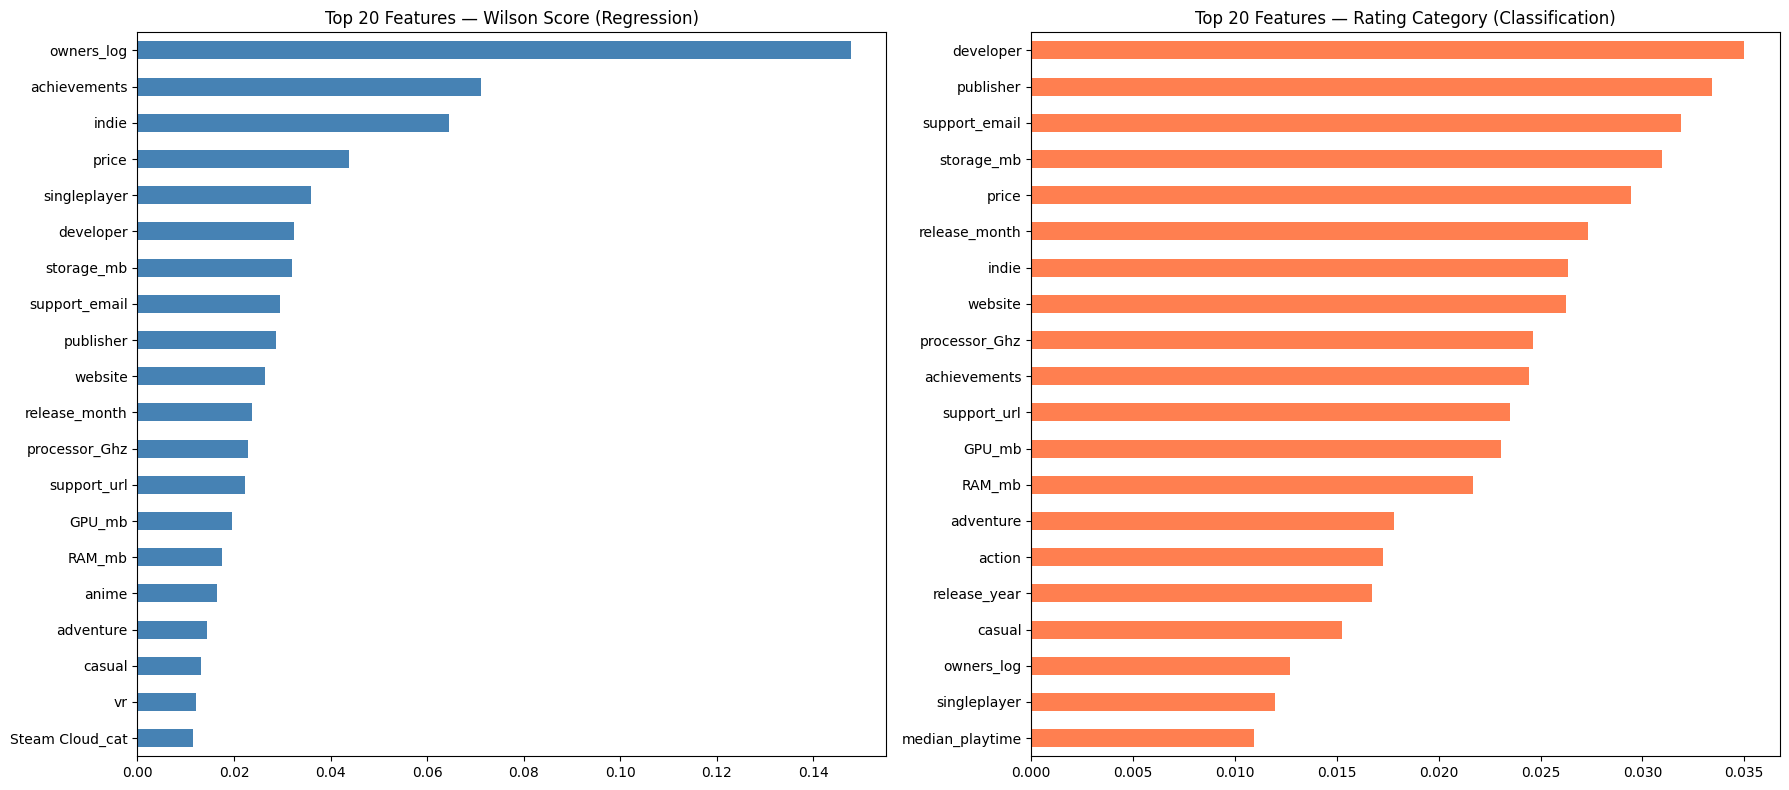

In [4]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

X = df_model

# Regression: Wilson Score
y_reg = df['wilson_score']

rf_reg = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
rf_reg.fit(X, y_reg)

imp_reg = pd.Series(rf_reg.feature_importances_, index=X.columns)
top_reg  = imp_reg.sort_values(ascending=False).head(20)

# Classification: Rating Category
y_clf = LabelEncoder().fit_transform(df['rating_category'])

rf_clf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
rf_clf.fit(X, y_clf)

imp_clf = pd.Series(rf_clf.feature_importances_, index=X.columns)
top_clf  = imp_clf.sort_values(ascending=False).head(20)

# Plotting stuff
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

top_reg.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Features — Wilson Score (Regression)')
axes[0].invert_yaxis()

top_clf.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 20 Features — Rating Category (Classification)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [6]:
# Save importance scores alongside feature names! 
importance_df = pd.DataFrame({
    'feature': imp_reg.index,
    'importance': imp_reg.values
}).sort_values('importance', ascending=False)

importance_df.to_csv('feature_importances.csv', index=False)

In [10]:
df_final = meta_cols.join(df_model)

# print(df_final.shape)
# print(df_final.columns.tolist())
# print(df_final.head(2))
df_final.to_csv('steam_finalized_dataset.csv', index=False)

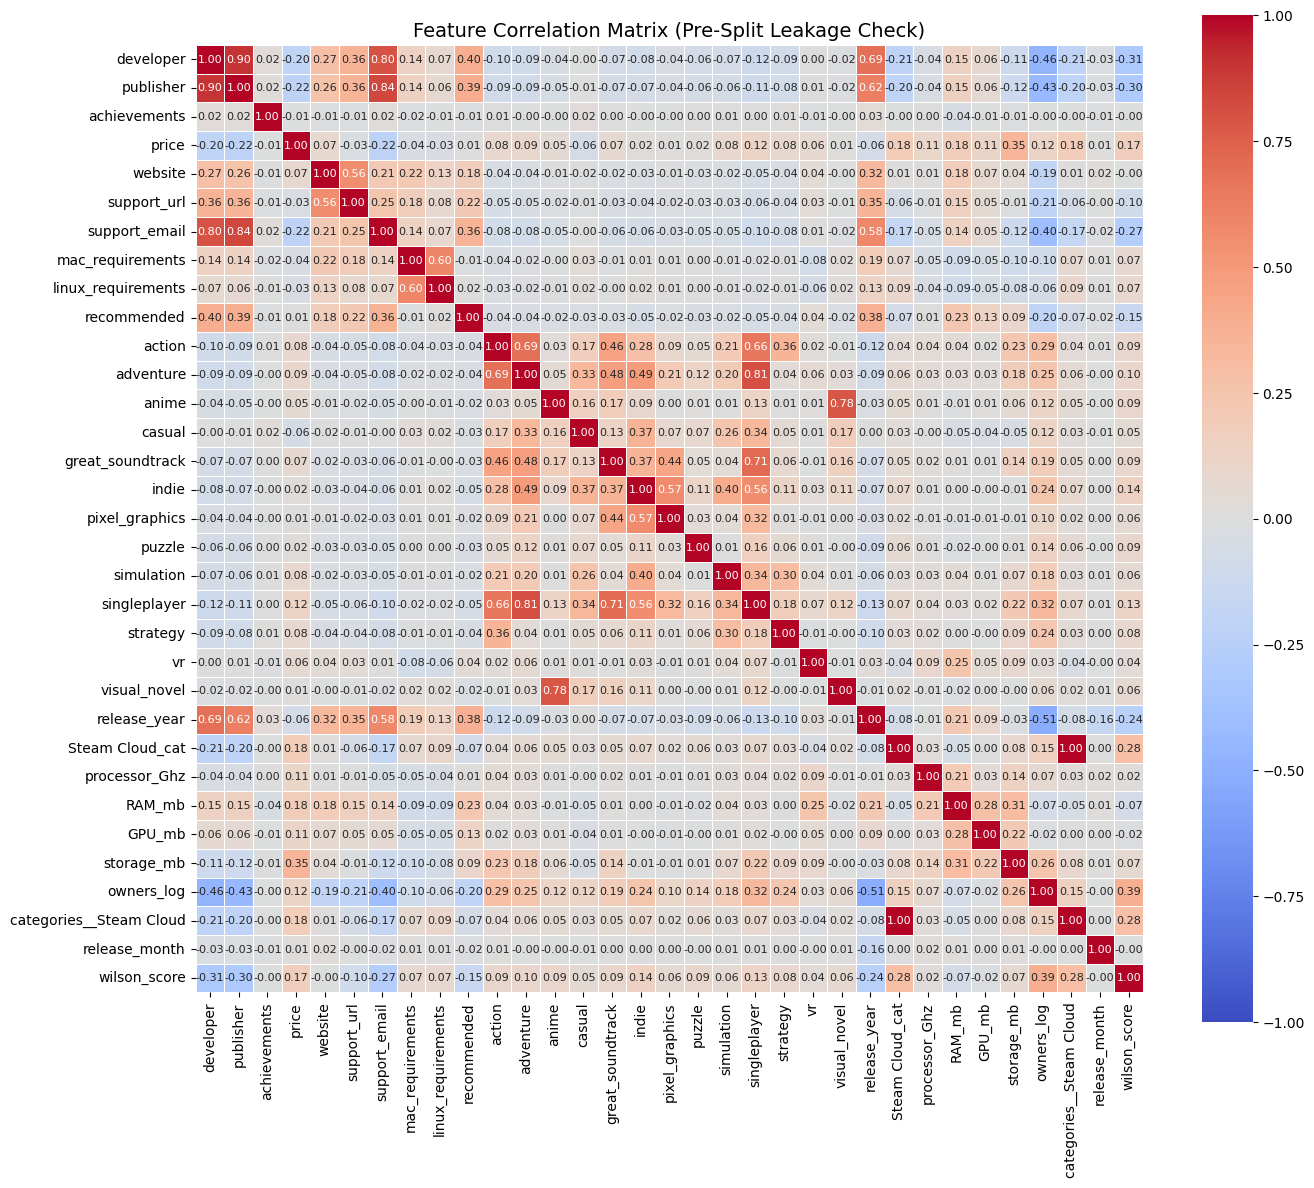

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt


selected_features = imp_reg[selected_features].index.tolist()

# Add wilson_score to check correlations WITH target
cols_to_check = selected_features + ['wilson_score']

# Pull wilson_score from original df, not df_model
corr_matrix = df_model[selected_features].join(df['wilson_score']).corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Feature Correlation Matrix (Pre-Split Leakage Check)', fontsize=14)
plt.tight_layout()
plt.show()

In [37]:
drop_redundant = [
    'publisher',            # redundant with developer
    'support_email',        # redundant with developer  
    'linux_requirements',   # redundant with mac_requirements
    'categories__Steam Cloud'  # exact duplicate of Steam_Cloud_cat
]

df_model = df_model[selected_features].drop(columns=drop_redundant)

df_model

,developer,achievements,price,website,support_url,mac_requirements,recommended,action,adventure,anime,...,vr,visual_novel,release_year,Steam Cloud_cat,processor_Ghz,RAM_mb,GPU_mb,storage_mb,owners_log,release_month
0,0,0,7.19,-1,0,0,-1,2681,0,0,...,0,0,2000,0,0.5,96.0,16.0,-1.0,16.523561,11
1,0,0,3.99,0,-1,0,-1,99,0,0,...,0,0,2003,0,0.5,96.0,16.0,-1.0,15.830414,5
2,1,0,3.99,-1,1,0,-1,211,87,0,...,0,0,1999,0,0.5,96.0,16.0,-1.0,15.830414,11
3,0,0,7.19,1,2,0,-1,766,306,0,...,0,0,1998,1,0.5,96.0,16.0,-1.0,15.830414,11
4,0,0,7.19,-1,3,1,-1,377,40,0,...,0,0,2004,0,0.5,96.0,16.0,-1.0,16.523561,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26816,17021,7,2.09,-1,10998,1,-1,0,21,0,...,0,0,2019,0,-1.0,2048.0,300.0,300.0,9.210440,4
26817,17022,0,1.69,-1,-1,1,-1,21,20,0,...,0,0,2019,0,2.5,4096.0,-1.0,300.0,9.210440,4
26818,7959,24,3.99,15177,5526,1,-1,21,0,0,...,0,0,2019,1,2.0,256.0,1024.0,100.0,9.210440,4
26819,5700,0,5.19,6706,1983,7996,12148,0,20,0,...,0,0,2019,1,1.5,750.0,512.0,500.0,9.210440,4
